
This notebook implements Ridge Regression from scratch using synthetic data. It compares Linear Regression, sklearn's Ridge (alpha=10, 100), and a custom MeraRidge class using closed-form solution m = num/(deno + alpha). The custom model achieved R² ≈ 0.407 with alpha=100, demonstrating how L2 regularization shrinks coefficients to reduce overfitting.

In [128]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

In [97]:
X,y = make_regression(n_samples=100, n_features =1,n_informative=1, n_targets=1,noise=20,random_state=13)

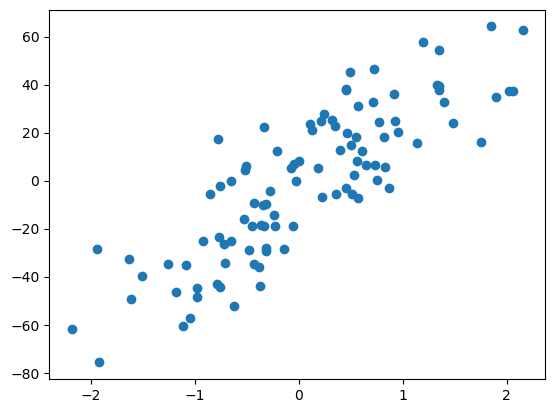

In [99]:
plt.scatter(X,y)

In [101]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [103]:
from sklearn.linear_model import LinearRegression

In [105]:
lr = LinearRegression()
lr.fit(X,y)

LinearRegression()

In [107]:
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [109]:
from sklearn.linear_model import Ridge

In [111]:
Reg = Ridge(alpha=10)

In [113]:
Reg.fit(X,y)

Ridge(alpha=10)

In [115]:
print(Reg.coef_)
print(Reg.intercept_)

[24.9546267]
-2.1269130035235726


In [117]:
rr1= Ridge(alpha=100)
rr1.fit(X,y)
print(rr1.coef_)
print(rr1.intercept_)


[12.93442104]
-1.4248441496033308


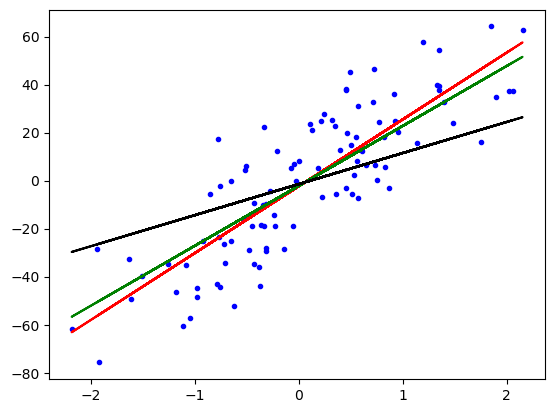

In [119]:
plt.plot(X,y,'b.')
plt.plot(X,lr.predict(X),color='red',label='alpha=0')
plt.plot(X,Reg.predict(X),color='green',label='alpha=10')
plt.plot(X,rr1.predict(X),color='black',label='alpha=100')

In [121]:
class MeraRidge:
    
    def __init__(self,alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None
        
    def fit(self,x_train,y_train):
        
        num = 0
        deno = 0
        
        for i in range(x_train.shape[0]):
            num = num + (y_train[i] - y_train.mean())* (x_train[i] - x_train.mean())
            deno = deno + (x_train[i] - x_train.mean())* (x_train[i] - x_train.mean()) 
    
        self.m = num/(deno + self.alpha)
        self.b = y_train.mean() - (self.m*x_train.mean())
        print(self.m,self.b)
       
     
    
    def predict(self,X_test):
        return np.dot(x_test,self.m) +self.b
        
       

In [123]:
reg = MeraRidge(alpha=100)

In [125]:
from sklearn.metrics import r2_score 
reg.fit(x_train,y_train)
y_pred = reg.predict(y_test)
r2_score(y_test,y_pred)

[11.58742415] [-2.30901805]


0.4077495941548199